# V2 Step 1b - Visual sense-check of FD001

Goal: look at the loaded, validated `train_FD001` data with our own eyes
before doing anything else to it. This notebook is exploratory only.

**Not in this notebook:** calculating RUL, engineering features, dropping
sensors, or training a model. We're just confirming the data loaded by
`src/cmapss_loader.py` looks like what we expect it to look like.

In [ ]:
# Notebooks run with notebooks/ as the working directory, so src/ isn't
# importable by default. Add the project root to sys.path (once) so we can
# `import src...` the same way the app and tests do - see pytest.ini.
import sys
from pathlib import Path

project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

from src.cmapss_loader import (
    OPERATIONAL_SETTING_COLUMNS,
    SENSOR_COLUMNS,
    load_train_fd001,
    validate_cmapss_dataframe,
)

pd.set_option("display.max_columns", None)

df = load_train_fd001()
validate_cmapss_dataframe(df, "train_FD001")
df.shape

(20631, 26)

## 1. First 20 rows

**What to check:** the columns look like what we expect (`unit_number`,
`time_cycles`, 3 operational settings, 21 sensors) - not shifted or
mislabeled. `unit_number` should start at 1, `time_cycles` should start at
1 and count up one row at a time within an engine. Sensor values should
look like plausible physical readings (temperatures, pressures, speeds),
not placeholder values like `-9999` or `0` across the board.

In [ ]:
df.head(20)

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,21.61,554.67,2388.02,9049.68,1.3,47.16,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,21.61,554.34,2388.02,9059.13,1.3,47.36,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,21.61,553.85,2388.00,9040.80,1.3,47.24,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,21.61,553.69,2388.05,9046.46,1.3,47.29,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,21.61,553.59,2388.05,9051.70,1.3,47.03,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


## 2. Last 20 rows

**What to check:** the last rows belong to the *last* engine (`unit_number`
100), at its *highest* cycle numbers - i.e. the end of that engine's
run-to-failure history. If `unit_number` here were lower than 100, or
`time_cycles` looked small, that would suggest the file didn't load in the
order we assume.

In [ ]:
df.tail(20)

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20611,100,181,0.0024,-0.0005,100.0,518.67,643.25,1597.83,1414.63,14.62,21.61,552.24,2388.18,9065.34,1.3,47.99,520.42,2388.22,8139.30,8.5518,0.03,396,2388,100.0,38.52,23.1774
20612,100,182,0.0007,-0.0001,100.0,518.67,643.52,1604.31,1417.73,14.62,21.61,551.47,2388.19,9063.62,1.3,47.75,520.05,2388.22,8140.87,8.4855,0.03,396,2388,100.0,38.41,23.1289
20613,100,183,-0.0011,-0.0002,100.0,518.67,643.34,1594.60,1427.27,14.62,21.61,551.83,2388.20,9066.08,1.3,48.00,520.64,2388.23,8144.21,8.5006,0.03,395,2388,100.0,38.49,23.0709
20614,100,184,0.0027,-0.0004,100.0,518.67,642.91,1598.88,1420.89,14.62,21.61,551.72,2388.25,9064.14,1.3,47.98,520.05,2388.20,8142.28,8.4989,0.03,396,2388,100.0,38.44,23.1229
20615,100,185,-0.0014,0.0004,100.0,518.67,643.95,1600.81,1420.34,14.62,21.61,551.92,2388.19,9069.95,1.3,47.75,520.71,2388.20,8142.32,8.4804,0.03,395,2388,100.0,38.60,23.2127
20616,100,186,0.0026,0.0004,100.0,518.67,643.61,1593.55,1425.32,14.62,21.61,552.28,2388.20,9066.46,1.3,48.06,520.66,2388.27,8138.08,8.4735,0.03,394,2388,100.0,38.51,23.1173
20617,100,187,0.0015,0.0002,100.0,518.67,643.63,1596.96,1421.49,14.62,21.61,551.53,2388.22,9065.94,1.3,48.04,520.15,2388.22,8140.49,8.5087,0.03,396,2388,100.0,38.67,23.2308
20618,100,188,-0.0008,-0.0002,100.0,518.67,643.19,1597.77,1426.57,14.62,21.61,550.77,2388.26,9067.68,1.3,48.29,519.98,2388.21,8139.94,8.4814,0.03,395,2388,100.0,38.36,23.0552
20619,100,189,0.0015,0.0001,100.0,518.67,643.69,1599.85,1423.15,14.62,21.61,551.61,2388.18,9069.69,1.3,47.99,519.50,2388.24,8139.78,8.4870,0.03,397,2388,100.0,38.65,23.0591
20620,100,190,-0.0001,0.0002,100.0,518.67,643.12,1594.45,1426.04,14.62,21.61,551.06,2388.21,9064.74,1.3,47.99,519.52,2388.26,8142.28,8.5162,0.03,395,2388,100.0,38.42,23.0603


## 3. All rows for engine/unit 1

**What to check:** `time_cycles` should run from 1 to that engine's maximum
with no gaps or repeats (we already checked this programmatically in
`validate_cmapss_dataframe`, but seeing the full run helps build intuition).
Watch the sensor columns as cycles increase - some should visibly drift
(early sign of the degradation we'll eventually predict), while some may
look essentially flat.

In [ ]:
df[df["unit_number"] == 1]

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,21.61,551.94,2388.31,9037.91,1.3,48.00,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,21.61,550.70,2388.27,9044.55,1.3,48.08,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,21.61,551.29,2388.29,9040.58,1.3,48.33,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,21.61,550.92,2388.28,9042.76,1.3,48.15,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


## 4. First 10 rows for engines 1, 2 and 3

**What to check:** FD001 has a single operating condition, so at cycle 1
the three `operational_setting` columns should look very similar across
different engines. Sensor readings will still differ engine-to-engine -
that's normal manufacturing variation between otherwise-identical engines,
not a data problem.

In [ ]:
for unit in [1, 2, 3]:
    display(df[df["unit_number"] == unit].head(10))

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,21.61,554.67,2388.02,9049.68,1.3,47.16,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,21.61,554.34,2388.02,9059.13,1.3,47.36,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,21.61,553.85,2388.00,9040.80,1.3,47.24,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,21.61,553.69,2388.05,9046.46,1.3,47.29,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,21.61,553.59,2388.05,9051.70,1.3,47.03,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
192,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,21.60,554.53,2388.01,9054.72,1.3,46.93,522.33,2388.06,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585
193,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,21.61,554.77,2387.98,9051.31,1.3,47.24,522.70,2387.98,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085
194,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,21.60,555.14,2388.04,9054.24,1.3,47.22,522.58,2387.99,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250
195,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,21.61,554.25,2387.98,9058.01,1.3,47.10,522.49,2387.93,8140.44,8.4018,0.03,391,2388,100.0,39.13,23.5027
196,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,21.60,555.12,2388.03,9058.15,1.3,47.25,522.27,2387.94,8136.67,8.3867,0.03,390,2388,100.0,39.18,23.4234
197,2,6,-0.0010,0.0004,100.0,518.67,641.30,1577.50,1396.76,14.62,21.61,554.98,2388.04,9054.07,1.3,47.05,522.80,2387.99,8133.65,8.3800,0.03,392,2388,100.0,39.15,23.4270
198,2,7,0.0001,-0.0002,100.0,518.67,642.03,1587.49,1400.65,14.62,21.61,554.84,2388.05,9052.67,1.3,47.10,522.14,2388.04,8136.33,8.3941,0.03,391,2388,100.0,39.10,23.4718
199,2,8,0.0015,-0.0004,100.0,518.67,642.55,1590.41,1395.39,14.62,21.61,554.65,2388.01,9055.82,1.3,47.20,522.77,2387.96,8137.92,8.3861,0.03,391,2388,100.0,39.11,23.4381
200,2,9,0.0017,-0.0004,100.0,518.67,641.98,1581.99,1395.01,14.62,21.60,554.69,2388.02,9051.67,1.3,47.14,522.40,2387.98,8145.29,8.3868,0.03,390,2388,100.0,39.06,23.4875
201,2,10,-0.0045,0.0002,100.0,518.67,641.99,1586.37,1394.86,14.62,21.60,554.63,2387.99,9058.88,1.3,47.21,521.99,2387.97,8138.64,8.3982,0.03,391,2388,100.0,39.20,23.6005


,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
479,3,1,0.0008,0.0005,100.0,518.67,642.04,1584.20,1398.13,14.62,21.61,553.96,2388.06,9056.95,1.3,47.14,522.24,2388.00,8138.40,8.4207,0.03,391,2388,100.0,38.96,23.3205
480,3,2,-0.0010,0.0000,100.0,518.67,642.66,1587.04,1398.62,14.62,21.61,554.76,2388.05,9059.67,1.3,47.35,522.03,2388.01,8137.38,8.3949,0.03,390,2388,100.0,39.07,23.4369
481,3,3,0.0013,-0.0002,100.0,518.67,642.07,1580.75,1401.10,14.62,21.61,554.51,2388.03,9050.43,1.3,46.94,522.16,2388.01,8137.20,8.3820,0.03,393,2388,100.0,39.03,23.3162
482,3,4,0.0008,-0.0002,100.0,518.67,642.50,1580.12,1395.76,14.62,21.61,554.48,2388.07,9060.43,1.3,47.44,522.31,2388.07,8139.35,8.3940,0.03,391,2388,100.0,38.94,23.4901
483,3,5,0.0020,0.0004,100.0,518.67,641.97,1581.48,1394.05,14.62,21.61,554.14,2388.01,9054.36,1.3,47.16,522.00,2388.03,8135.99,8.4233,0.03,391,2388,100.0,38.90,23.4190
484,3,6,-0.0010,-0.0003,100.0,518.67,642.65,1581.26,1397.98,14.62,21.61,554.86,2388.08,9048.62,1.3,47.12,522.58,2388.08,8137.99,8.4126,0.03,392,2388,100.0,39.04,23.4656
485,3,7,-0.0018,-0.0003,100.0,518.67,642.62,1583.68,1405.76,14.62,21.61,554.29,2388.06,9051.91,1.3,47.26,522.08,2388.01,8141.85,8.4369,0.03,393,2388,100.0,39.03,23.4051
486,3,8,0.0017,-0.0005,100.0,518.67,642.23,1581.60,1401.86,14.62,21.61,554.11,2388.00,9059.59,1.3,47.13,521.87,2388.06,8141.47,8.4197,0.03,392,2388,100.0,38.85,23.3564
487,3,9,0.0000,0.0003,100.0,518.67,642.60,1581.04,1398.30,14.62,21.61,554.61,2387.99,9060.04,1.3,47.16,522.47,2388.09,8136.84,8.4151,0.03,392,2388,100.0,39.02,23.3873
488,3,10,-0.0009,0.0003,100.0,518.67,642.72,1582.20,1400.07,14.62,21.61,554.28,2388.00,9053.42,1.3,47.22,522.40,2388.05,8130.42,8.4063,0.03,392,2388,100.0,38.96,23.3129


## 5. Each engine's maximum cycle

Each engine in the training set runs until failure, so its maximum
`time_cycles` value is that engine's full observed lifetime. We are **not**
calling this RUL - RUL is a per-row label (`max_cycle - current_cycle`)
that we calculate later in Step 2. This table is just the raw maximum,
shown for all 100 engines.

**What to check:** lifetimes should vary noticeably across engines (that's
expected - real degradation timing isn't identical machine to machine) but
stay within a plausible range, with no single engine wildly out of line
(e.g. a lifetime of 1 cycle, or 10,000 cycles, would suggest bad data).

In [ ]:
max_cycle_per_engine = (
    df.groupby("unit_number")["time_cycles"].max().rename("max_cycle").reset_index()
)
print(f"{len(max_cycle_per_engine)} engines")
max_cycle_per_engine

100 engines


,unit_number,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
...,...,...
95,96,336
96,97,202
97,98,156
98,99,185


In [ ]:
max_cycle_per_engine["max_cycle"].describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: max_cycle, dtype: float64

## 6. Descriptive statistics - operational settings and sensors

**What to check:** look at `std` (standard deviation) for each column.
A `std` of (or very close to) zero means that column never changes across
the whole dataset - it's carrying no information. `min`/`max` should be
physically plausible ranges, not obviously corrupted (huge outliers,
negative values where none should exist).

In [ ]:
df[OPERATIONAL_SETTING_COLUMNS + SENSOR_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
operational_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
operational_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
operational_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600


## 7. Number of unique values per sensor

**What to check:** a sensor with only 1 unique value across 20,631 rows is
completely constant - it cannot help predict anything, no matter what model
we use later. A sensor with a handful of unique values may be a discrete
setting rather than a continuous measurement. Sensors with many thousands
of unique values are behaving like normal continuous telemetry. We're only
*observing* this here - no columns are being dropped in this notebook.

In [ ]:
df[SENSOR_COLUMNS].nunique().sort_values()

sensor_1        1
sensor_19       1
sensor_18       1
sensor_5        1
sensor_16       1
sensor_10       1
sensor_6        2
sensor_17      13
sensor_8       53
sensor_13      56
sensor_20     120
sensor_11     159
sensor_2      310
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

## Plots

Still exploratory only - no RUL, no features, no model. These plots exist
to *see* degradation and lifetime patterns, to build intuition before we
touch the data programmatically in Step 2.

### Sensor values over time for engine 1

We pick a small selection of sensors to plot rather than all 21, to keep
the plots readable. We use the unique-value counts from step 7 to avoid
wasting a plot on a sensor we already know is flat - a flat line tells us
nothing we didn't already know.

Plotting: ['sensor_9', 'sensor_14', 'sensor_21', 'sensor_4', 'sensor_3', 'sensor_15']


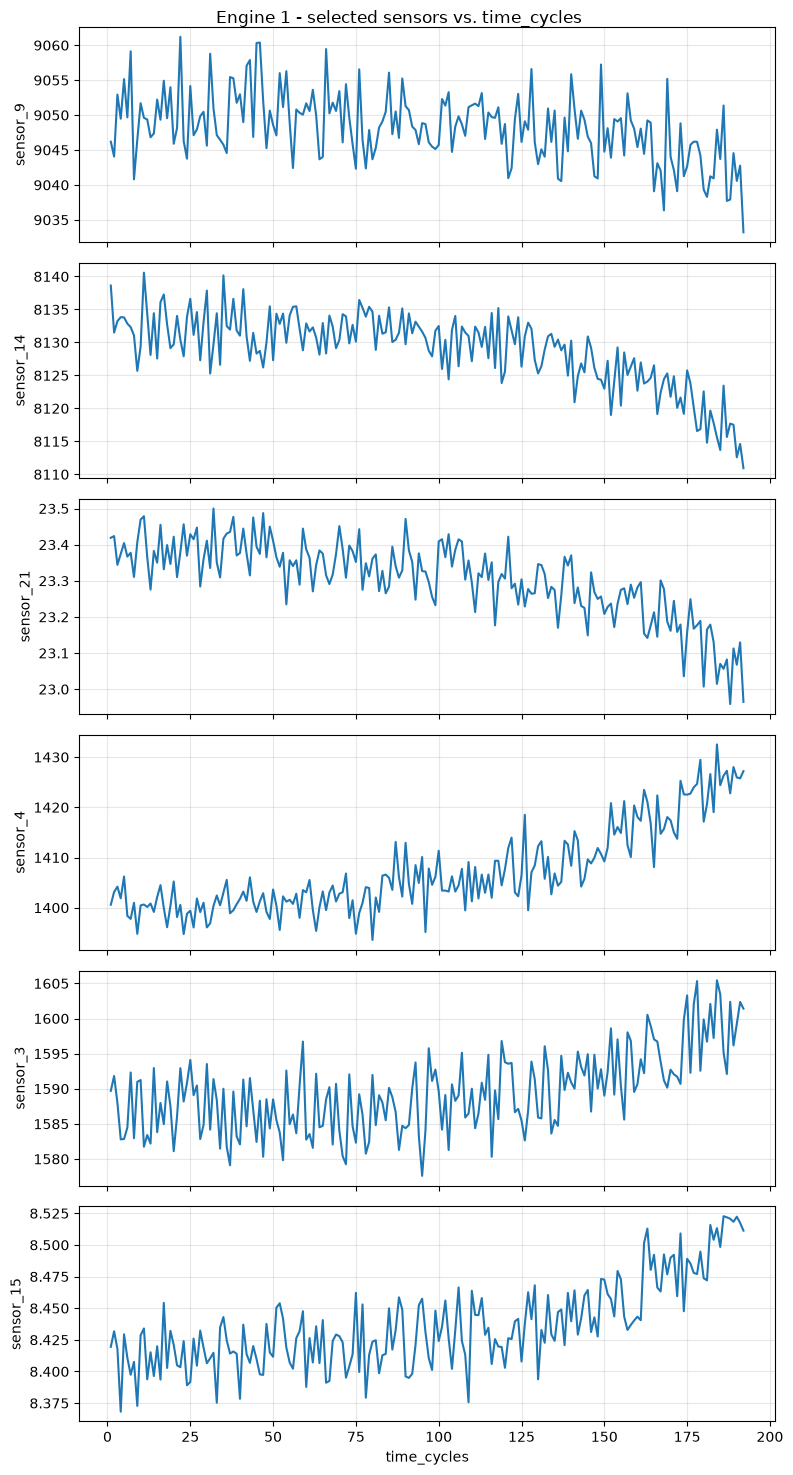

In [ ]:
unique_counts = df[SENSOR_COLUMNS].nunique().sort_values(ascending=False)
selected_sensors = list(unique_counts.head(6).index)
print("Plotting:", selected_sensors)

engine_1 = df[df["unit_number"] == 1]

fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(8, 2.5 * len(selected_sensors)), sharex=True)
for ax, sensor in zip(axes, selected_sensors):
    ax.plot(engine_1["time_cycles"], engine_1[sensor])
    ax.set_ylabel(sensor)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("time_cycles")
fig.suptitle("Engine 1 - selected sensors vs. time_cycles")
fig.tight_layout()
plt.show()

**What to check:** watch for a visible trend as cycles increase (rising,
falling, or accelerating change near the end) - that's the degradation
signal a RUL model would eventually need to learn from. A sensor that's
just noise around a flat mean, with no trend, is less likely to be useful
later.

### Maximum lifetime per engine, across all 100 engines

Same `max_cycle_per_engine` table from step 5, shown as a plot instead of a
table - easier to spot the spread and any outliers at a glance.

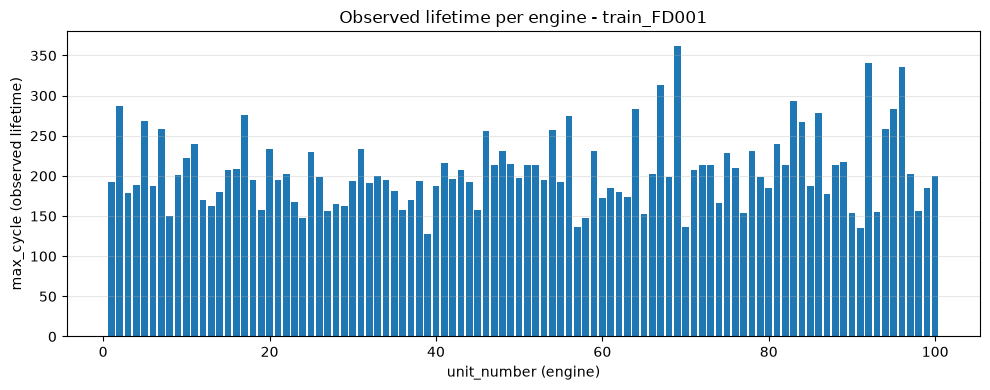

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(max_cycle_per_engine["unit_number"], max_cycle_per_engine["max_cycle"])
ax.set_xlabel("unit_number (engine)")
ax.set_ylabel("max_cycle (observed lifetime)")
ax.set_title("Observed lifetime per engine - train_FD001")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

**What to check:** a wide, roughly continuous spread of bar heights is
expected (engines fail at different points). A cluster of engines all
failing at *exactly* the same cycle count, or one bar far taller/shorter
than every other, would be worth investigating before trusting the data.